In [1]:
import pandas as pd
import numpy as np

In [2]:
data_combined= pd.read_csv("data/sleephealthlifestyle/data_gender_combined.csv")

In [3]:
data_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   gender                    374 non-null    object 
 1   age_group                 374 non-null    object 
 2   age                       374 non-null    int64  
 3   occupation                374 non-null    object 
 4   sleep_duration            374 non-null    float64
 5   quality_of_sleep          374 non-null    int64  
 6   physical_activity_level   374 non-null    int64  
 7   stress_level              374 non-null    int64  
 8   bmi_category              374 non-null    object 
 9   blood_pressure_systolic   374 non-null    int64  
 10  blood_pressure_diastolic  374 non-null    int64  
 11  heart_rate                374 non-null    int64  
 12  daily_steps               374 non-null    int64  
 13  sleep_disorder            155 non-null    object 
dtypes: float64

In [4]:
data_combined.head()

,gender,age_group,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,daily_steps,sleep_disorder
0,Female,Young Adult,29,Nurse,6.5,5,40,7,Normal Weight,132,87,80,4000,Sleep Apnea
1,Female,Young Adult,29,Nurse,6.5,5,40,7,Normal Weight,132,87,80,4000,Insomnia
2,Female,Young Adult,30,Nurse,6.4,5,35,7,Normal Weight,130,86,78,4100,Sleep Apnea
3,Female,Young Adult,30,Nurse,6.4,5,35,7,Normal Weight,130,86,78,4100,Insomnia
4,Female,Young Adult,31,Nurse,7.9,8,75,4,Normal Weight,117,76,69,6800,NaN


In [5]:
data_combined.duplicated().sum()

np.int64(242)

In [6]:

data_combined = data_combined.drop_duplicates()


print(data_combined.shape)  


(132, 14)


In [7]:
data_combined.to_csv("data_combined_clean.csv", index=False)


In [8]:
data_combined.isnull().sum()


gender                       0
age_group                    0
age                          0
occupation                   0
sleep_duration               0
quality_of_sleep             0
physical_activity_level      0
stress_level                 0
bmi_category                 0
blood_pressure_systolic      0
blood_pressure_diastolic     0
heart_rate                   0
daily_steps                  0
sleep_disorder              73
dtype: int64

In [9]:
data_combined['sleep_disorder'] = data_combined['sleep_disorder'].fillna('No sleep disorder')


In [10]:
data_combined['sleep_disorder'].value_counts()

sleep_disorder
No sleep disorder    73
Sleep Apnea          30
Insomnia             29
Name: count, dtype: int64

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Nurse'),
  Text(1, 0, 'Scientist'),
  Text(2, 0, 'Accountant'),
  Text(3, 0, 'Teacher'),
  Text(4, 0, 'Lawyer'),
  Text(5, 0, 'Manager'),
  Text(6, 0, 'Engineer'),
  Text(7, 0, 'Doctor'),
  Text(8, 0, 'Software Engineer'),
  Text(9, 0, 'Sales Representative'),
  Text(10, 0, 'Salesperson')])

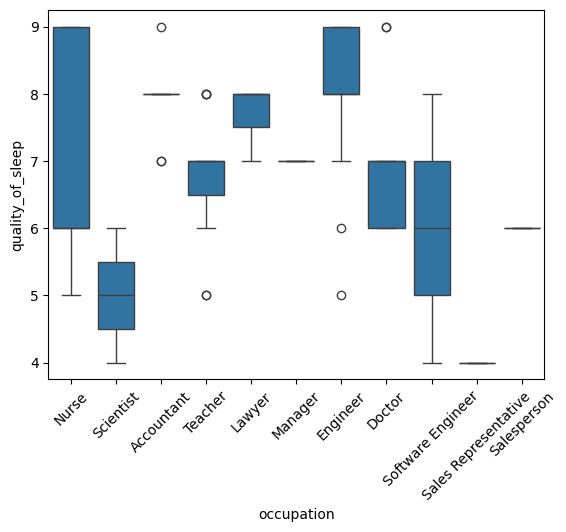

In [12]:
sns.boxplot(x='occupation', y='quality_of_sleep', data=data_combined)
plt.xticks(rotation=45)


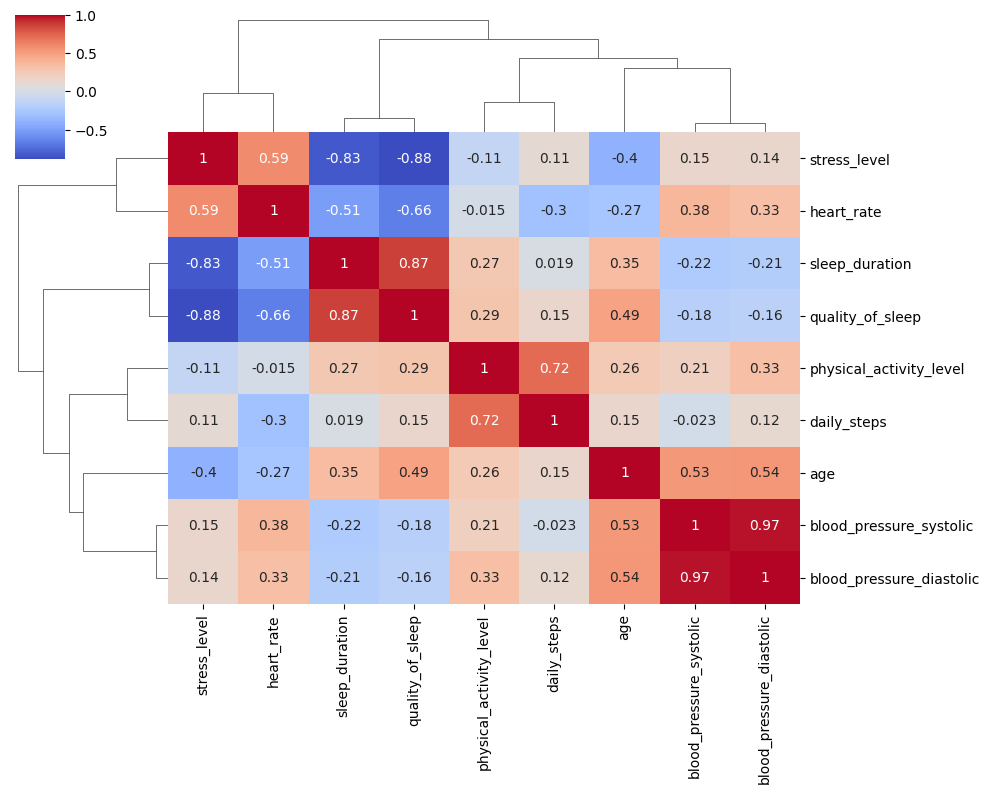

In [13]:
corr = data_combined.corr(numeric_only=True)
sns.clustermap(corr, annot=True, cmap="coolwarm", figsize=(10, 8))


In [14]:

data_combined['bp_mean'] = (data_combined['blood_pressure_systolic'] + data_combined['blood_pressure_diastolic']) / 2


data_combined['sleep_score'] = data_combined['sleep_duration'] * data_combined['quality_of_sleep']


data_combined['activity_index'] = (data_combined['physical_activity_level'] + (data_combined['daily_steps'] / 1000)) / 2


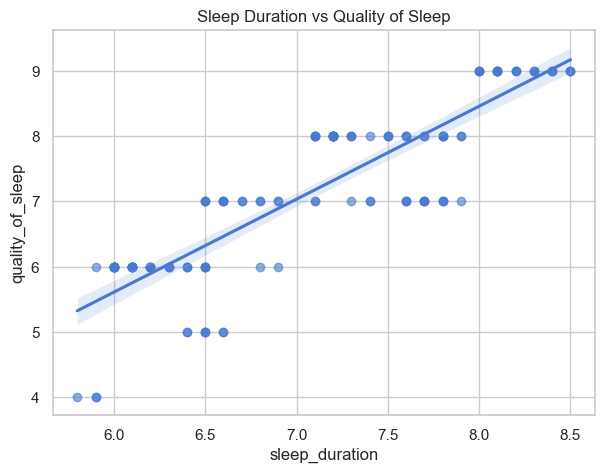

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="muted")

plt.figure(figsize=(7,5))
sns.regplot(x="sleep_duration", y="quality_of_sleep", data=data_combined, scatter_kws={'alpha':0.6})
plt.title("Sleep Duration vs Quality of Sleep")
plt.show()


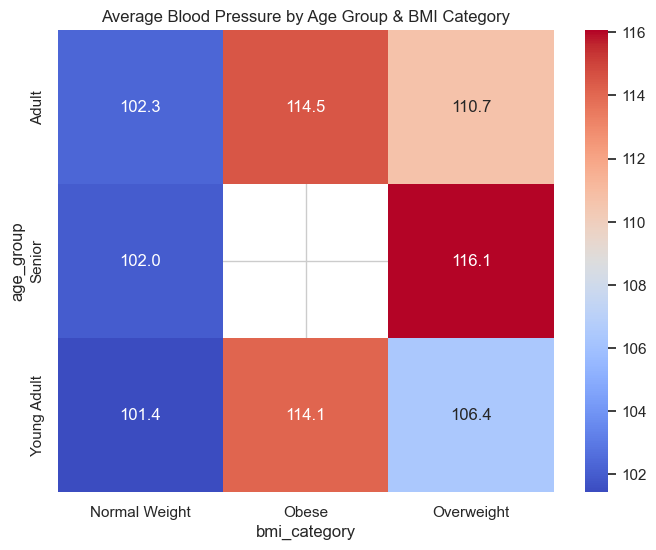

In [16]:
bp_avg = data_combined.groupby(['age_group', 'bmi_category'])['bp_mean'].mean().reset_index()
bp_pivot = bp_avg.pivot(index='age_group', columns='bmi_category', values='bp_mean')

plt.figure(figsize=(8,6))
sns.heatmap(bp_pivot, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Average Blood Pressure by Age Group & BMI Category")
plt.show()


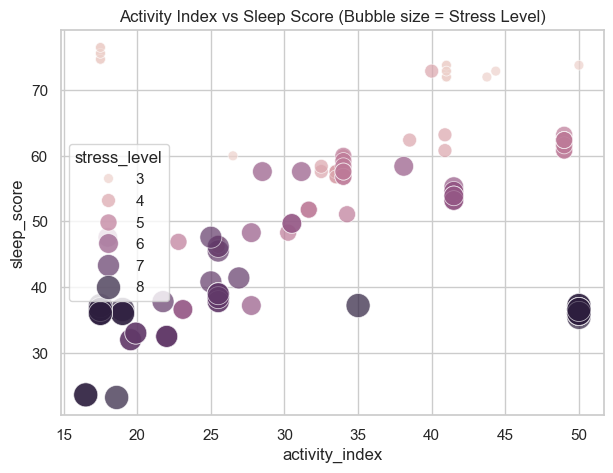

In [17]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="activity_index", 
    y="sleep_score", 
    size="stress_level", 
    hue="stress_level", 
    data=data_combined, 
    sizes=(50, 300), 
    alpha=0.7
)
plt.title("Activity Index vs Sleep Score (Bubble size = Stress Level)")
plt.show()


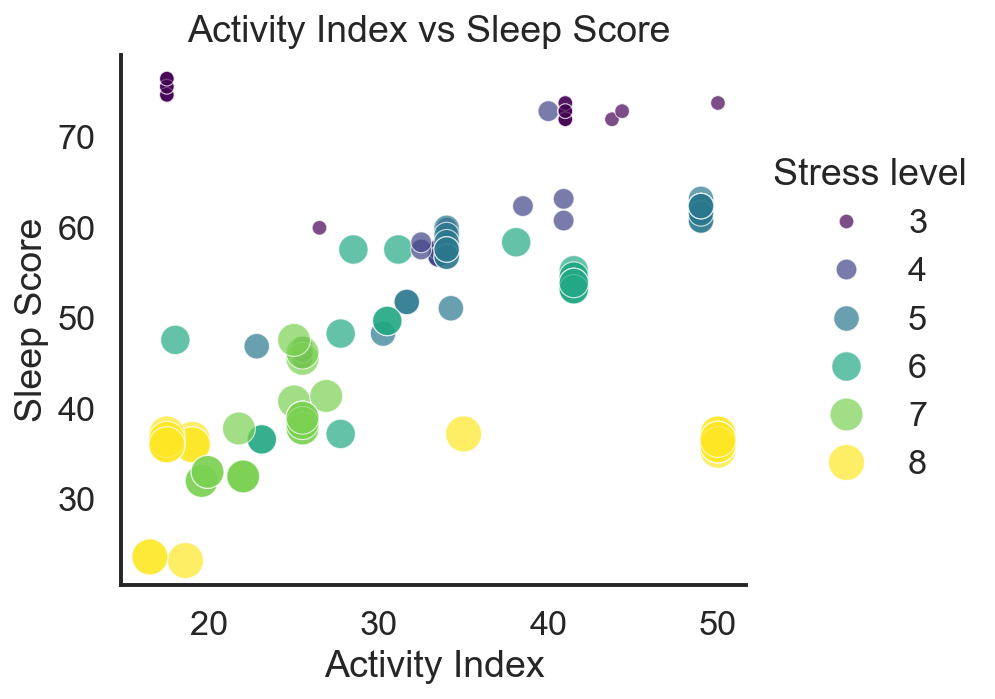

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Style (no grid) ---
sns.set_style("white")                 # clean look, no grid
sns.set_context("talk")                # slightly larger labels for slides

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

sns.scatterplot(
    data=data_combined,
    x="activity_index",
    y="sleep_score",
    hue="stress_level",
    size="stress_level",
    sizes=(50, 300),
    alpha=0.7,
    legend="brief",                    # one combined legend for hue+size
    palette="viridis",
    ax=ax
)

# Labels & title
ax.set_xlabel("Activity Index")
ax.set_ylabel("Sleep Score")
ax.set_title("Activity Index vs Sleep Score ")

# Remove grid & make frame minimal
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Move the (single) legend outside
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    title="Stress level",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

# Layout and save for PowerPoint
fig.tight_layout()
fig.savefig("activity_vs_sleep_stress.png", dpi=300, bbox_inches="tight", transparent=True)
fig.savefig("activity_vs_sleep_stress.svg", bbox_inches="tight")   # crisp vector for resizing

plt.show()


C:\Users\Eleonora\AppData\Local\Temp\ipykernel_12236\138616597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="stress_level", y="heart_rate", data=data_combined, inner="quart", palette="Set2")


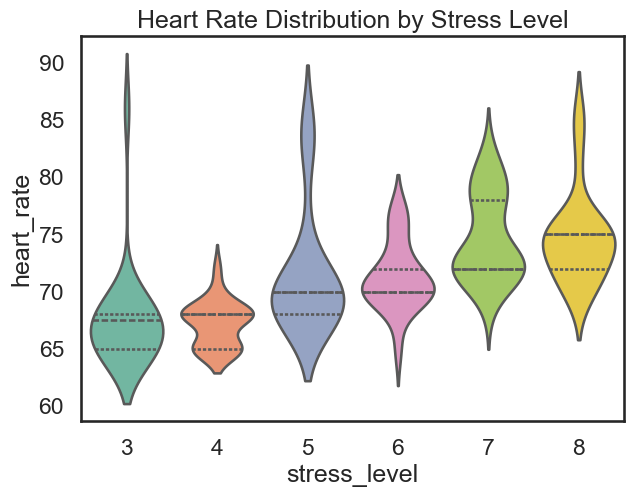

In [19]:
plt.figure(figsize=(7,5))
sns.violinplot(x="stress_level", y="heart_rate", data=data_combined, inner="quart", palette="Set2")
plt.title("Heart Rate Distribution by Stress Level")
plt.show()


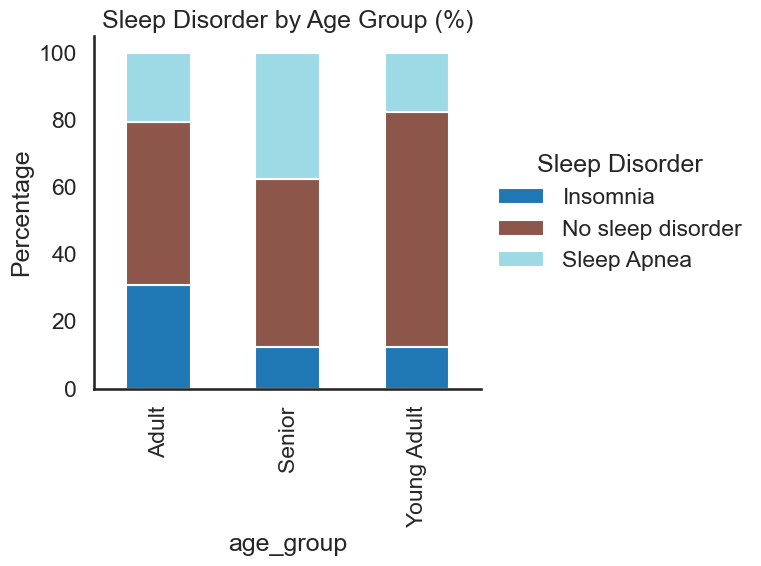

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Cross-tab with percentages
cross_tab = pd.crosstab(
    data_combined['age_group'], 
    data_combined['sleep_disorder'], 
    normalize='index'
) * 100

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8,6))

# Plot stacked bar
cross_tab.plot(
    kind='bar', 
    stacked=True, 
    colormap="tab20", 
    ax=ax
)

# Remove grid + extra spines
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Labels & title
ax.set_ylabel('Percentage')
ax.set_title("Sleep Disorder by Age Group (%)")

# Move legend outside
ax.legend(
    title="Sleep Disorder",
    bbox_to_anchor=(1.02, 0.5),   # outside on the right
    loc="center left",
    borderaxespad=0.,
    frameon=False
)

# Adjust layout and save (PPT ready)
fig.tight_layout()
fig.savefig("sleep_disorder.png", dpi=300, bbox_inches="tight", transparent=True)


plt.show()


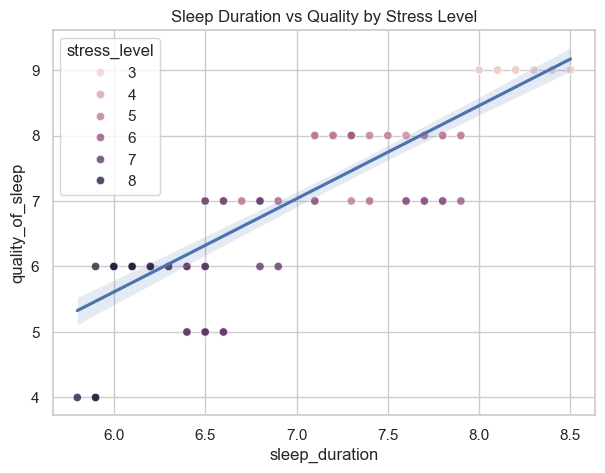

In [21]:


sns.set(style="whitegrid")
plt.figure(figsize=(7,5))
sns.scatterplot(data=data_combined, x="sleep_duration", y="quality_of_sleep", hue="stress_level", alpha=0.8)
sns.regplot(data=data_combined, x="sleep_duration", y="quality_of_sleep", scatter=False)  # overall trend
plt.title("Sleep Duration vs Quality by Stress Level")
plt.show()


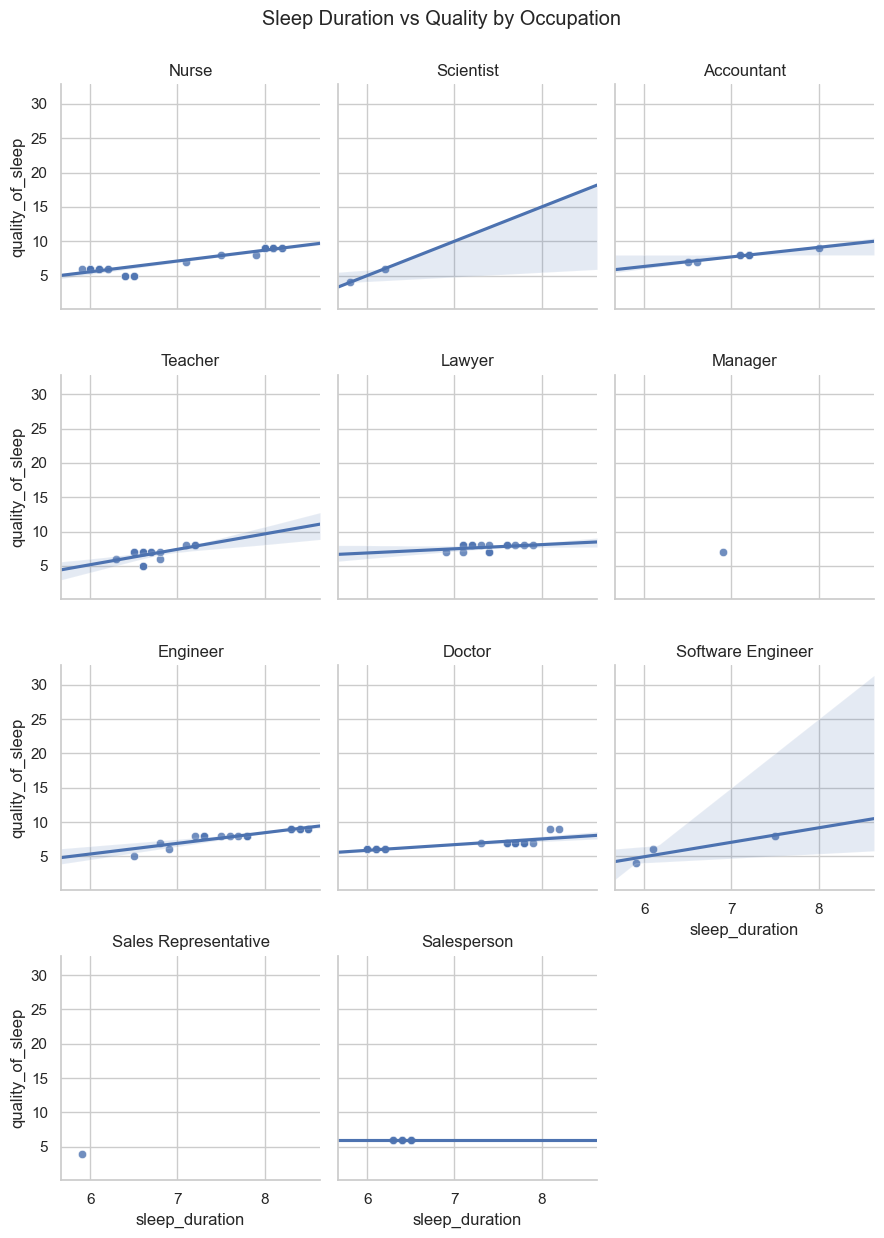

In [22]:
g = sns.FacetGrid(data_combined, col="occupation", col_wrap=3, height=3)
g.map_dataframe(sns.scatterplot, x="sleep_duration", y="quality_of_sleep", alpha=0.8)
g.map_dataframe(sns.regplot, x="sleep_duration", y="quality_of_sleep", scatter=False, truncate=False)
g.set_titles("{col_name}")
g.fig.suptitle("Sleep Duration vs Quality by Occupation", y=1.03)
plt.show()


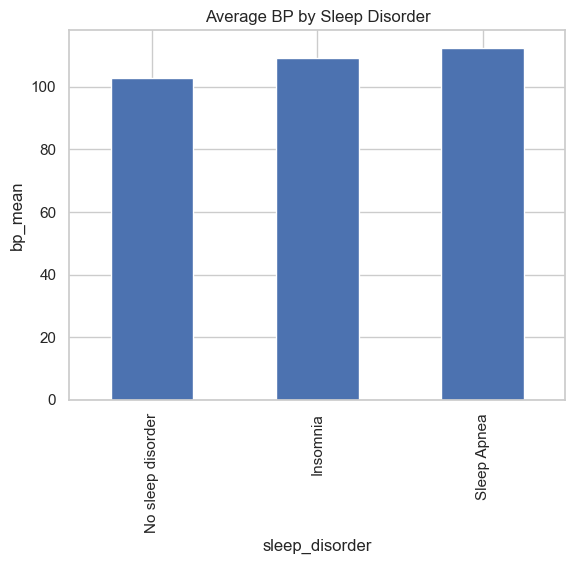

In [23]:
data_combined['bp_mean'] = (data_combined['blood_pressure_systolic'] + data_combined['blood_pressure_diastolic'])/2

ax = (data_combined
      .groupby("sleep_disorder")["bp_mean"]
      .mean()
      .sort_values()
      .plot(kind="bar"))
ax.set_title("Average BP by Sleep Disorder")
ax.set_ylabel("bp_mean")
plt.show()


             activity_index  sleep_score
stress_band                             
Low                    31.9         64.6
Medium                 37.3         54.5
High                   28.8         36.3


C:\Users\Eleonora\AppData\Local\Temp\ipykernel_12236\4250044232.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("stress_band")[["activity_index","sleep_score"]]


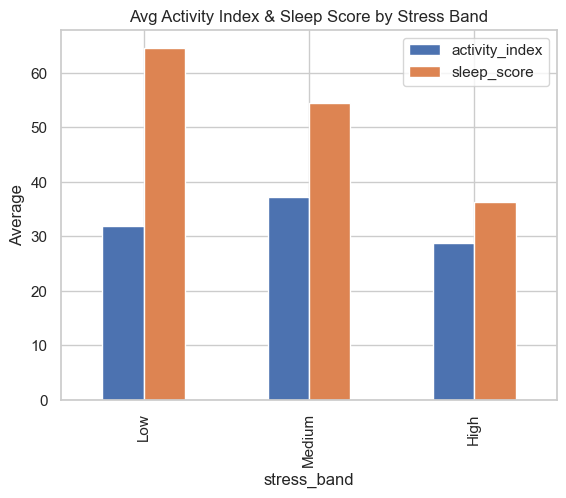

In [24]:


bins = [0,4,6,10]         # adjust if your stress scale differs
labels = ["Low","Medium","High"]
data_combined["stress_band"] = pd.cut(data_combined["stress_level"], bins=bins, labels=labels, include_lowest=True)

summary = (data_combined
           .groupby("stress_band")[["activity_index","sleep_score"]]
           .mean()
           .round(1))
print(summary)

summary.plot(kind="bar")
plt.title("Avg Activity Index & Sleep Score by Stress Band")
plt.ylabel("Average")
plt.show()


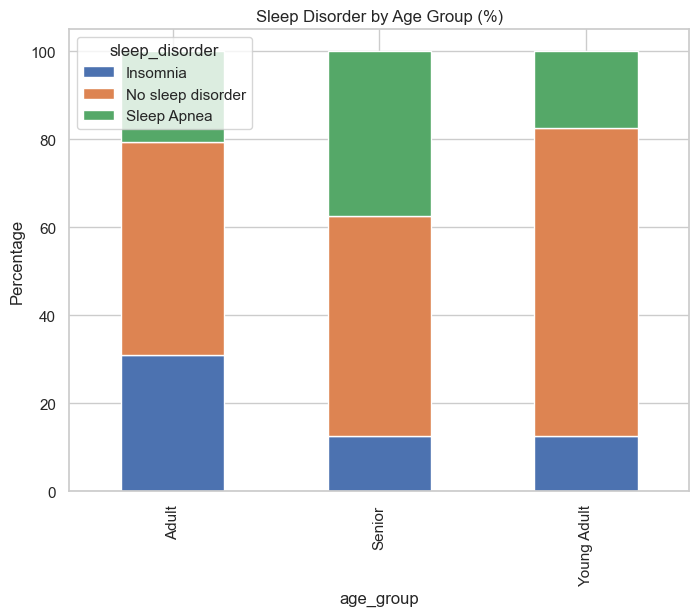

In [25]:
clean = data_combined.query("sleep_disorder != 'Unknown'")

ct = pd.crosstab(clean['age_group'], clean['sleep_disorder'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, figsize=(8,6))
plt.ylabel("Percentage")
plt.title("Sleep Disorder by Age Group (%)" )
plt.show()


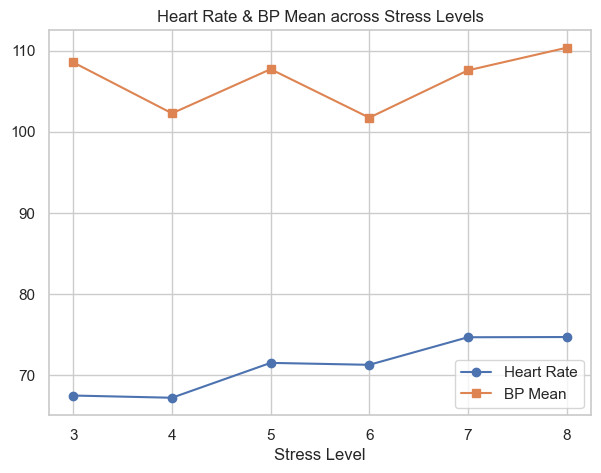

In [26]:
means = (data_combined
         .groupby("stress_level")[["heart_rate","bp_mean"]]
         .mean()
         .reset_index())

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(means["stress_level"], means["heart_rate"], marker="o", label="Heart Rate")
ax.plot(means["stress_level"], means["bp_mean"], marker="s", label="BP Mean")
ax.set_xlabel("Stress Level")
ax.set_title("Heart Rate & BP Mean across Stress Levels")
ax.legend()
plt.show()


In [27]:
print("corr(stress, heart_rate):", data_combined["stress_level"].corr(data_combined["heart_rate"]))
print("corr(stress, bp_mean):   ", data_combined["stress_level"].corr(data_combined["bp_mean"]))


corr(stress, heart_rate): 0.5924678991344977
corr(stress, bp_mean):    0.14709996690602156


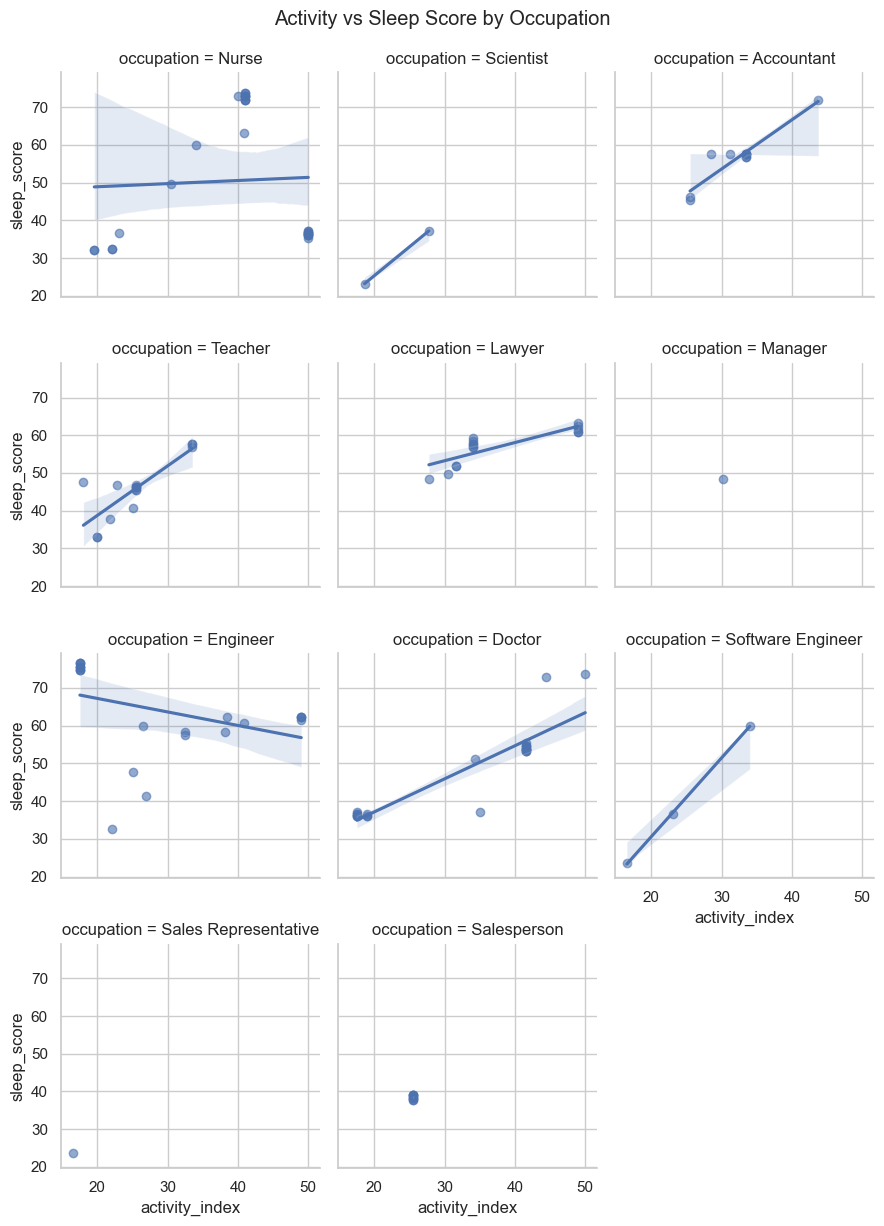

In [28]:
min_count = 10

occ_counts = data_combined['occupation'].value_counts()
valid_occupations = occ_counts[occ_counts >= min_count].index

filtered_df = data_combined[data_combined['occupation'].isin(valid_occupations)]

g = sns.lmplot(
    data=data_combined,
    x="activity_index",
    y="sleep_score",
    col="occupation",
    col_wrap=3,
    height=3,
    scatter_kws=dict(alpha=0.6),
    line_kws=dict()
)
g.fig.suptitle("Activity vs Sleep Score by Occupation", y=1.02)
plt.show()


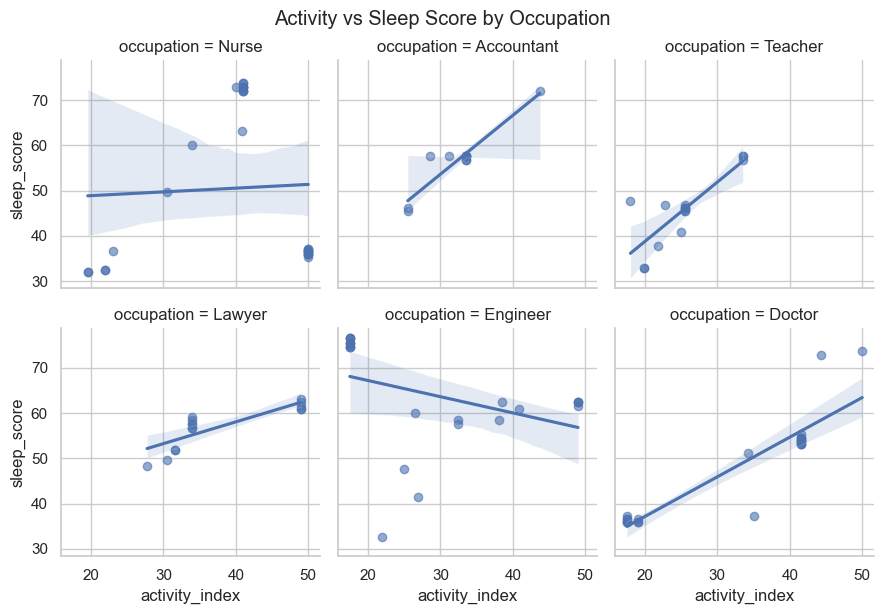

In [29]:

min_count = 10

occ_counts = data_combined['occupation'].value_counts()

valid_occupations = occ_counts[occ_counts >= min_count].index

filtered_df = data_combined.loc[data_combined['occupation'].isin(valid_occupations)].copy()

g = sns.lmplot(
    data=filtered_df,
    x="activity_index",
    y="sleep_score",
    col="occupation",
    col_wrap=3,
    height=3,
    scatter_kws=dict(alpha=0.6),
    line_kws=dict()
)
g.fig.suptitle("Activity vs Sleep Score by Occupation", y=1.02)
fig.tight_layout()
fig.savefig("activity_vs_sleep_by_Occupation.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()


In [30]:
data_combined['physical_activity_level'].value_counts()


physical_activity_level
75    23
60    22
30    21
90    21
45    20
40     5
55     4
35     4
50     3
70     2
42     2
32     1
80     1
47     1
65     1
85     1
Name: count, dtype: int64

In [31]:
import scipy.stats as stats

results = []

for level in sorted(data_combined['physical_activity_level'].unique()):
    subset = data_combined[data_combined['physical_activity_level'] == level]
    
    male_quality = subset[subset['gender'] == 'Male']['quality_of_sleep']
    female_quality = subset[subset['gender'] == 'Female']['quality_of_sleep']
    
   
    if len(male_quality) >= 2 and len(female_quality) >= 2:
        t_stat, p_val = stats.ttest_ind(male_quality, female_quality, equal_var=False)
        results.append((level, len(male_quality), len(female_quality), t_stat, p_val))

results_df = pd.DataFrame(results, columns=['Activity_Level', 'Male_n', 'Female_n', 'T_stat', 'P_value'])

print(results_df)


   Activity_Level  Male_n  Female_n     T_stat       P_value
0              30      11        10 -10.029193  6.141379e-09
1              35       2         2        NaN           NaN
2              40       3         2   1.732051  2.254033e-01
3              45      11         9  -2.745632  1.467447e-02
4              60      11        11  -0.845154  4.120863e-01
5              75      12        11 -14.804512  1.858757e-12
6              90       9        12   7.000000  2.269597e-05


c:\Users\Eleonora\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


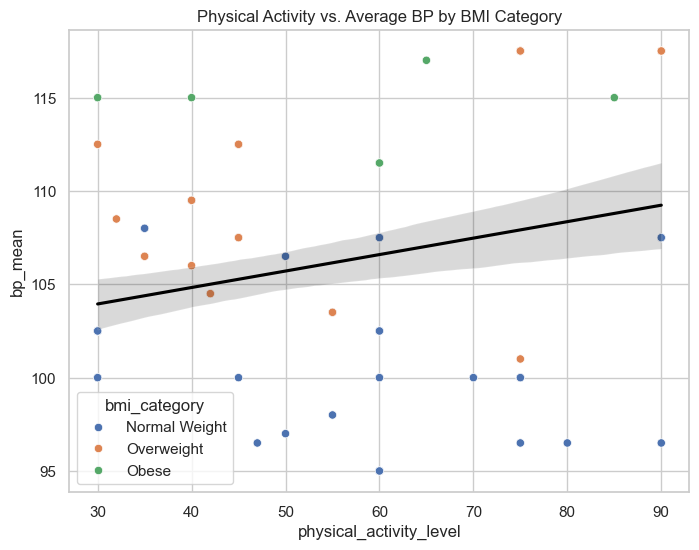

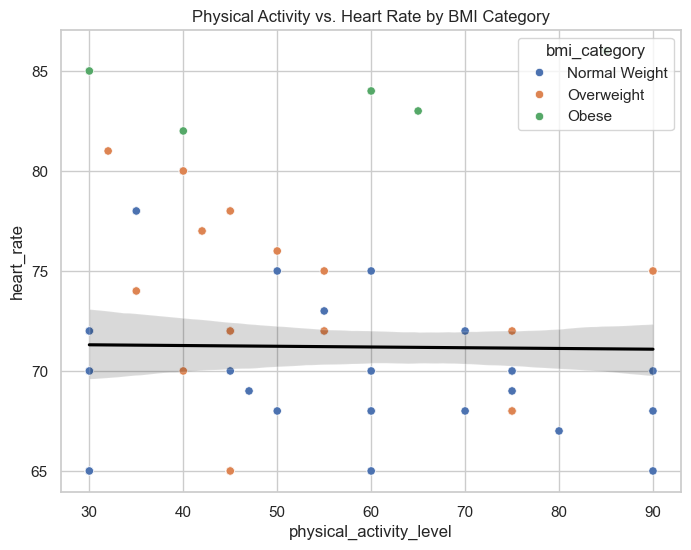

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data_combined, x='physical_activity_level', y='bp_mean', hue='bmi_category')
sns.regplot(data=data_combined, x='physical_activity_level', y='bp_mean', scatter=False, color='black')
plt.title("Physical Activity vs. Average BP by BMI Category")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=data_combined, x='physical_activity_level', y='heart_rate', hue='bmi_category')
sns.regplot(data=data_combined, x='physical_activity_level', y='heart_rate', scatter=False, color='black')
plt.title("Physical Activity vs. Heart Rate by BMI Category")
plt.show()


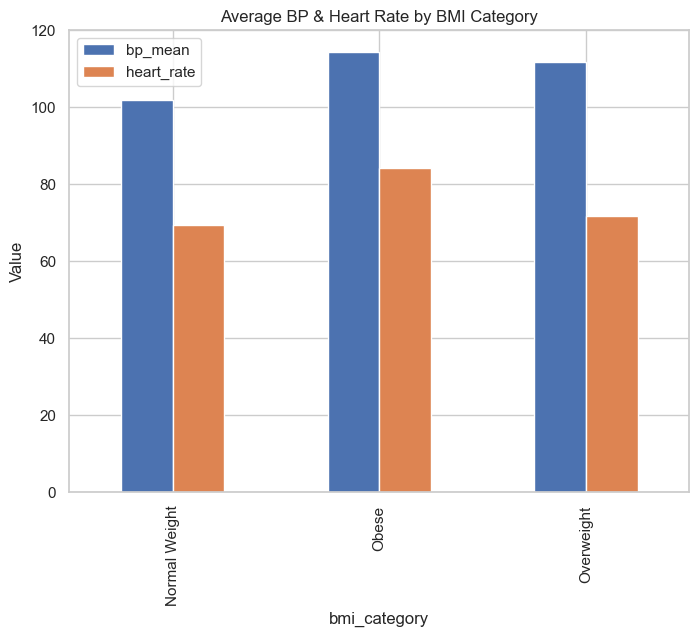

In [33]:
avg_bp_hr = data_combined.groupby('bmi_category')[['bp_mean','heart_rate']].mean().reset_index()

avg_bp_hr.plot(x='bmi_category', kind='bar', figsize=(8,6))
plt.title("Average BP & Heart Rate by BMI Category")
plt.ylabel("Value")
plt.show()


C:\Users\Eleonora\AppData\Local\Temp\ipykernel_12236\3525980423.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=avg_bp_hr_gender_melted,


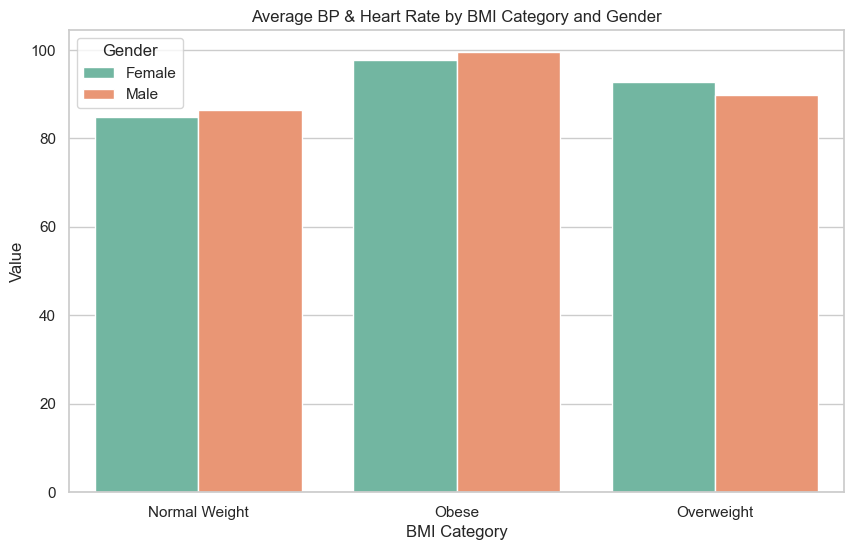

In [34]:
# Group by BMI category and gender
avg_bp_hr_gender = data_combined.groupby(['bmi_category', 'gender'])[['bp_mean','heart_rate']].mean().reset_index()

# Create a grouped bar chart
avg_bp_hr_gender_melted = avg_bp_hr_gender.melt(id_vars=['bmi_category','gender'], 
                                                value_vars=['bp_mean','heart_rate'], 
                                                var_name='Metric', value_name='Value')

plt.figure(figsize=(10,6))
sns.barplot(data=avg_bp_hr_gender_melted, 
            x='bmi_category', y='Value', hue='gender', 
            palette='Set2', ci=None)

plt.title("Average BP & Heart Rate by BMI Category and Gender")
plt.ylabel("Value")
plt.xlabel("BMI Category")
plt.legend(title="Gender")
plt.show()
